# Reproducción de fidelidad: Wei et al. (2021), QCNN con filtro LCU, MNIST y Fashion-MNIST

**Objetivo**: validar que el QCNN de Wei, Chen, Zhou & Long (2021), *"A Quantum
Convolutional Neural Network on NISQ Devices"* (arXiv:2104.06918v3), reproduce
con fidelidad razonable la exactitud publicada (96.3%, sin ruido) bajo el
protocolo de entrenamiento de este benchmark. Notebook exploratorio de
validación — no un adaptador de producción. No toca `qcnn_bench`, el registro
de plugins, ni el notebook de Hur (`01_reproduce_hur.ipynb`).

## Hallazgo importante resuelto antes de escribir este notebook

`external/wei_qcnn/` **no es una implementación fiel de Wei et al.** Es en
realidad el repositorio `qml-benchmarks` de Xanadu (paper distinto: *"Better
than classical? The subtle art of benchmarking quantum machine learning
models"*). Su clase `WeiNet` cita el arXiv de Wei et al. en el docstring, pero
el propio código admite explícitamente tomar atajos:

- Usa un filtro 3×3 **fijo, no entrenable** (`edge_detect`, `smooth` o
  `sharpen`), no 9 parámetros aprendibles.
- **No modela el registro de ancillas** — el código dice literalmente *"we
  don't model the ancilla qubits themselves"* y lo sustituye por una mezcla
  clásica de 9 unitarios fijos.
- Su lectura no es un hamiltoniano fijo de 37 parámetros, sino un vector de
  tamaño genérico dependiente del número de qubits.

Se verificó el paper original (`/Users/marielalvarez/2026/6toSem/NGS/2104.06918v3.pdf`,
extraído con `pdftotext`) y se confirmó, con cita directa, que la
especificación de esta tarea es correcta y que el par de clases 1-vs-8 **sí**
es el que usa el propio paper (a diferencia del caso de Hur, aquí no hubo que
corregir el par de clases):

> "the work register of QCNN consists of 10 qubits and the ancillary register
> needs 4 qubits. The convolutional layer is characterized by 9 learnable
> parameters ... by abandoning the 4-th and 9-th qubit of the work register,
> we perform the pooling layer ... the QCNN's parametrized Hamiltonian has 37
> learnable parameters."

Tabla I del paper: "Noise-free QCNN", tarea "'1' or '8'", 46 parámetros
(9+37), exactitud de prueba = **0.963**.

**Decisión tomada con el usuario**: dado que no existe código vendorizado fiel
a esta arquitectura, el circuito se reconstruye directamente de las ecuaciones
del paper (Fig. 2, Ec. 10–16, Apéndice B) en vez de partir de
`external/wei_qcnn`. Además, como la validación de hoy es el caso **sin
ruido** (analítico), la post-selección de las 4 ancillas en $|0000\rangle$ se
implementa como su equivalente matemático exacto — la combinación lineal
directa $\sum_k \beta_k Q_k|f\rangle$, normalizada — en vez de simular
explícitamente el registro de 14 qubits con puertas controladas y
post-selección. Ambas cosas dan el mismo resultado en el caso sin ruido; la
versión con ancillas explícitas quedaría para cuando se implemente ejecución
con ruido/shots.

## 1. Atribución y licencia

`external/wei_qcnn/` (Apache-2.0, Copyright 2024 Xanadu Quantum Technologies
Inc., ver `external/wei_qcnn/LICENSE`) **no se usa como base del circuito**
por las razones explicadas arriba — su arquitectura (`WeiNet`) diverge
fundamentalmente de la especificación de esta tarea. Se documenta su licencia
aquí de todas formas porque el repositorio sigue vendorizado en este proyecto
y una pieza matemática puntual suya se reutiliza (ver abajo).

```
Copyright 2024 Xanadu Quantum Technologies Inc.

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

Cita del paper del que se deriva el circuito de este notebook:

```bibtex
@article{wei2021quantum,
  title={A Quantum Convolutional Neural Network on NISQ Devices},
  author={Wei, ShiJie and Chen, YanHu and Zhou, ZengRong and Long, GuiLu},
  journal={arXiv preprint arXiv:2104.06918},
  year={2021}
}
```

### Qué se reutiliza de `external/wei_qcnn` (una sola pieza matemática, no la arquitectura)

El paper describe los operadores de desplazamiento $E_1, E_2=I, E_3=E_1^\dagger$
del Apéndice B solo de forma pictórica (matrices con unos fuera de la
diagonal). `external/wei_qcnn/.../weinet.py` realiza ese mismo primitivo como
un desplazamiento cíclico módulo $M$ (`V[i, (i+k) % height] = ...`). Esa
realización concreta (desplazamiento cíclico) es consistente con la figura del
paper y se reutiliza aquí **solo para ese primitivo puntual** (implementado
como `numpy.roll`, ver sección de circuito) — no se reutiliza nada más de ese
archivo, cuya arquitectura completa (filtro fijo, sin ancillas, lectura de
tamaño genérico) fue rechazada por no coincidir con la especificación.

### Qué se construye nuevo, directamente del paper (Fig. 2, Ec. 10–16, Apéndice B)

- 10 qubits de registro de trabajo (imagen 32×32 = 1024 amplitudes, cero-
  rellenada desde 28×28), sin PCA — codificación de amplitud directa.
- Capa convolucional: 9 parámetros entrenables $\beta_1, \dots, \beta_9$ (uno
  por cada desplazamiento relativo $(\Delta_\text{fila}, \Delta_\text{col}) \in
  \{-1,0,1\}^2$), combinados como combinación lineal de unitarios (LCU) —
  ver nota sobre post-selección exacta arriba.
- Pooling: se descartan los qubits de trabajo 4 y 9 (numeración del paper,
  1-indexada; en este notebook, wires 3 y 8, 0-indexados), dejando 8 qubits
  activos.
- Lectura: hamiltoniano de 37 parámetros ($h_0 I + \sum_i h_i Z_i + \sum_{i<j}
  h_{ij} Z_i Z_j$, con $1 + 8 + 28 = 37$ sobre los 8 qubits que sobreviven al
  pooling), seguido de sigmoide.
- El ciclo de entrenamiento (BCE, Adam, recorte de gradiente, early stopping)
  es el mismo protocolo nuevo escrito para `01_reproduce_hur.ipynb` — no existe
  en ningún repositorio de referencia, es específico de este benchmark. Única
  diferencia respecto a Hur: inicialización de pesos $\mathcal{N}(0, 0.1)$ en
  vez de uniforme, según la especificación de esta tarea.

In [1]:
import os
import sys
import time
import pathlib
import warnings

import certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())  # ver nota mas abajo

import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import autograd.numpy as anp
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Advertencia benigna: default.qubit representa el estado internamente en
# complex128; expval de operadores hermitianos (Identity/PauliZ/PauliZ@PauliZ)
# es siempre real, pero autograd castea el resultado complejo->real al hacer
# el backward pass a traves de qml.StatePrep, generando este warning conocido.
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

# Fix para el error "SSL: CERTIFICATE_VERIFY_FAILED" de los instaladores de
# python.org en macOS (no relacionado con pennylane/sklearn) -- apunta
# SSL_CERT_FILE al bundle de certifi ya instalado en este mismo .venv, sin
# tocar nada fuera del proyecto.

PROJECT_ROOT = pathlib.Path.cwd().resolve()
while not (PROJECT_ROOT / "external").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Entorno: se espera ejecutar este notebook con el kernel del .venv aislado del proyecto")
print("(ver notebooks/dev/01_reproduce_hur.ipynb, seccion de higiene de entorno).")
print("PROJECT_ROOT:", PROJECT_ROOT)

Entorno: se espera ejecutar este notebook con el kernel del .venv aislado del proyecto
(ver notebooks/dev/01_reproduce_hur.ipynb, seccion de higiene de entorno).
PROJECT_ROOT: /Users/marielalvarez/2026/6toSem/NGS/benchmark_multifactorial_iee


## 2. Carga de datos y representación (codificación de amplitud, 1024 = 32×32)

Muestreo estratificado balanceado, igual que en el notebook de Hur: 500
entrenamiento / 250 validación / 500 prueba por clase, semilla `20260802`. Sin
PCA — imagen 28×28 rellenada con ceros a 32×32, aplanada a 1024 valores,
normalizada en norma L2 (requisito de la codificación de amplitud).

In [ ]:
SAMPLE_SEED = 20260802
N_TRAIN_PER_CLASS = 500
N_VAL_PER_CLASS = 250
N_TEST_PER_CLASS = 500
IMG_SIZE = 28
PAD_SIZE = 32  # 32*32 = 1024 = 2**10, exactamente 10 qubits de registro de trabajo


def stratified_split(x_all, y_all, class_pos, class_neg, seed=SAMPLE_SEED):
    '''500/250/500 por clase, balanceado, semilla fija. class_pos -> etiqueta 1.'''
    rng = np.random.default_rng(seed)
    splits = {"train": [], "val": [], "test": []}
    label_of = {}
    for cls in sorted([class_pos, class_neg]):
        idx_cls = np.where(y_all == cls)[0]
        n_needed = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + N_TEST_PER_CLASS
        assert len(idx_cls) >= n_needed, f"clase {cls} solo tiene {len(idx_cls)} muestras"
        idx_cls = rng.permutation(idx_cls)
        train_idx = idx_cls[:N_TRAIN_PER_CLASS]
        val_idx = idx_cls[N_TRAIN_PER_CLASS : N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
        test_idx = idx_cls[
            N_TRAIN_PER_CLASS + N_VAL_PER_CLASS : N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + N_TEST_PER_CLASS
        ]
        splits["train"].append(train_idx)
        splits["val"].append(val_idx)
        splits["test"].append(test_idx)
        label_of[cls] = 1 if cls == class_pos else 0

    out = {}
    for split_name, idx_list in splits.items():
        idx = np.concatenate(idx_list)
        x = x_all[idx]  
        y = np.array([label_of[c] for c in y_all[idx]], dtype=np.float64)
        out[f"X_{split_name}"] = x
        out[f"y_{split_name}"] = y
    return out


def amplitude_representation(raw_splits):
    '''Cero-relleno 28x28 -> 32x32, aplanado a 1024, normalizado en norma L2.
    Sin ajuste/fit (a diferencia de la PCA de Hur): es una transformacion fija,
    por lo que no hay riesgo de fuga de datos entre splits.'''
    pad = (PAD_SIZE - IMG_SIZE) // 2
    out = {}
    for split in ("train", "val", "test"):
        x = raw_splits[f"X_{split}"]
        n = x.shape[0]
        imgs = x.reshape(n, IMG_SIZE, IMG_SIZE).astype(np.float64)
        padded = np.zeros((n, PAD_SIZE, PAD_SIZE), dtype=np.float64)
        padded[:, pad : pad + IMG_SIZE, pad : pad + IMG_SIZE] = imgs
        flat = padded.reshape(n, PAD_SIZE * PAD_SIZE)
        norms = np.linalg.norm(flat, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        out[f"X_{split}"] = flat / norms
        out[f"y_{split}"] = raw_splits[f"y_{split}"]
    return out


def build_dataset(class_pos, class_neg, x_all, y_all):
    raw = stratified_split(x_all, y_all, class_pos, class_neg)
    rep = amplitude_representation(raw)
    for split in ("train", "val", "test"):
        assert rep[f"X_{split}"].shape[1] == PAD_SIZE * PAD_SIZE
        norms = np.linalg.norm(rep[f"X_{split}"], axis=1)
        assert np.allclose(norms, 1.0, atol=1e-6), f"normas fuera de rango en {split}"
        print(f"  {split}: {rep[f'X_{split}'].shape}, norma L2 promedio = {norms.mean():.6f}")
    return rep

## 3. Circuito: filtro LCU de 9 parámetros + pooling (qubits 4, 9) + hamiltoniano de 37 parámetros

Ver sección de atribución para la derivación completa. Resumen: (1) los 9
$\beta_k$ parametrizan la combinación lineal de los 9 desplazamientos
relativos del filtro 3×3 sobre la imagen 32×32 (implementados como
desplazamientos cíclicos, `numpy.roll`, sobre las dos dimensiones espaciales);
(2) el resultado se normaliza (equivalente exacto de post-seleccionar las 4
ancillas en $|0000\rangle$ en el caso sin ruido); (3) el estado de 10 qubits
resultante se prepara con `qml.StatePrep` y se mide un hamiltoniano de 37
parámetros sobre los 8 qubits que sobreviven al pooling.

In [3]:
N_WORK_QUBITS = 10
N_FILTER_PARAMS = 9
POOLED_LABELS_1INDEXED = {4, 9}  # "abandoning the 4-th and 9-th qubit of the work register" (paper)
POOLED_WIRES = {lbl - 1 for lbl in POOLED_LABELS_1INDEXED}  # 0-indexado: {3, 8}
SURVIVING_WIRES = [w for w in range(N_WORK_QUBITS) if w not in POOLED_WIRES]
assert len(SURVIVING_WIRES) == 8

# k=1..9 en orden fila-mayor sobre los desplazamientos relativos, igual que el
# orden de la matriz W en la Ec.(19) del paper (filas = desplazamiento de
# fila, columnas = desplazamiento de columna)
OFFSETS = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]
assert len(OFFSETS) == N_FILTER_PARAMS

# Hamiltoniano de 37 parametros: identidad + 8 Z + 28 ZZ = 1 + 8 + 28 = 37
HAMILTONIAN_OPS = [qml.Identity(0)]
for w in SURVIVING_WIRES:
    HAMILTONIAN_OPS.append(qml.PauliZ(w))
for i in range(len(SURVIVING_WIRES)):
    for j in range(i + 1, len(SURVIVING_WIRES)):
        HAMILTONIAN_OPS.append(qml.PauliZ(SURVIVING_WIRES[i]) @ qml.PauliZ(SURVIVING_WIRES[j]))
N_HAMILTONIAN_PARAMS = len(HAMILTONIAN_OPS)
assert N_HAMILTONIAN_PARAMS == 37

TOTAL_PARAMS = N_FILTER_PARAMS + N_HAMILTONIAN_PARAMS  # 46, coincide con la Tabla I del paper

dev_wei = qml.device("default.qubit", wires=N_WORK_QUBITS)


@qml.qnode(dev_wei)
def readout_circuit(state_vector, h):
    '''Prepara el estado post-convolucion+post-seleccion (10 qubits) y mide
    el hamiltoniano de 37 parametros, con los 37 pesos entrenables h pasados
    directamente al qnode (qml.Hamiltonian con coeficientes entrenables) en
    vez de recolectar una lista de expval y multiplicar afuera -- mas robusto
    numericamente y el patron idiomatico de PennyLane para esta operacion.
    El pooling (qubits 4, 9 descartados) no requiere una traza parcial
    explicita: los operadores de HAMILTONIAN_OPS ya excluyen esos dos wires,
    y <estado|O|estado> para un operador que no actua sobre un qubit es
    invariante a trazarlo o no.'''
    qml.StatePrep(state_vector, wires=range(N_WORK_QUBITS))
    return qml.expval(qml.Hamiltonian(h, HAMILTONIAN_OPS))


def conv_lcu_state(f_flat, beta):
    '''Capa convolucional: combinacion lineal de los 9 Q_k (desplazamientos
    ciclicos 2D), normalizada -- equivalente exacto (caso sin ruido) de
    preparar las 4 ancillas, aplicar los Q_k controlados y post-seleccionar
    |0000>. Ver seccion de atribucion.'''
    f_2d = anp.reshape(f_flat, (PAD_SIZE, PAD_SIZE))
    raw = 0.0
    for k, (dr, dc) in enumerate(OFFSETS):
        shifted = anp.roll(anp.roll(f_2d, dr, axis=0), dc, axis=1)
        raw = raw + beta[k] * anp.reshape(shifted, (-1,))
    norm = anp.sqrt(anp.sum(raw ** 2))
    return raw / norm


def forward_logit(x_flat, params):
    '''x_flat: imagen aplanada (1024,), ya normalizada en L2 (representacion).
    params: vector de 46 parametros entrenables (9 filtro + 37 hamiltoniano).'''
    beta = params[:N_FILTER_PARAMS]
    h = params[N_FILTER_PARAMS:]
    g = conv_lcu_state(x_flat, beta)
    return readout_circuit(g, h)


print("Parametros entrenables:", TOTAL_PARAMS, "(9 filtro + 37 hamiltoniano, Tabla I del paper: 46)")
print("Wires descartados por pooling (0-indexados):", sorted(POOLED_WIRES), "-> qubits", sorted(POOLED_LABELS_1INDEXED), "en la numeracion del paper")

# Verificacion rapida
_rng_check = np.random.default_rng(0)
_params_check = pnp.array(_rng_check.normal(0, 0.1, TOTAL_PARAMS), requires_grad=True)
_x_check = _rng_check.uniform(0, 1, PAD_SIZE * PAD_SIZE)
_x_check = _x_check / np.linalg.norm(_x_check)
_logit_check = forward_logit(_x_check, _params_check)
print("Logit de ejemplo:", float(_logit_check))

Parametros entrenables: 46 (9 filtro + 37 hamiltoniano, Tabla I del paper: 46)
Wires descartados por pooling (0-indexados): [3, 8] -> qubits [4, 9] en la numeracion del paper
Logit de ejemplo: -0.12748998528016875


## 4. Ciclo de entrenamiento

Mismo protocolo exacto que `01_reproduce_hur.ipynb`: BCE, Adam (lr=0.01,
β1=0.9, β2=0.999), 200 actualizaciones, lote de 25, recorte de norma global de
gradiente a 5.0, early stopping (paciencia 5 chequeos de validación cada 10
actualizaciones, δ=1e-4), selección de checkpoint por menor pérdida de
validación. **Única diferencia**: inicialización de pesos
$\mathcal{N}(0, 0.1)$ en vez de uniforme, según la especificación de esta
tarea. Una sola semilla de ejecución por ahora.

In [4]:
RUN_SEED = 0
BATCH_SIZE = 25
N_UPDATES = 200
LEARNING_RATE = 0.01
BETA1, BETA2 = 0.9, 0.999
CLIP_NORM = 5.0
VAL_CHECK_EVERY = 10
PATIENCE_CHECKS = 5
MIN_DELTA = 1e-4


def cross_entropy_loss(params, X_batch, y_batch):
    '''BCE promediada sobre el lote (mismo criterio que 01_reproduce_hur.ipynb).'''
    total = 0.0
    for x, y in zip(X_batch, y_batch):
        logit = forward_logit(x, params)
        p = 1.0 / (1.0 + anp.exp(-logit))
        total = total + (y * anp.log(p) + (1 - y) * anp.log(1 - p))
    return -total / len(y_batch)


def clip_grad_global_norm(grad, max_norm=CLIP_NORM):
    norm = float(pnp.linalg.norm(grad))
    if norm > max_norm:
        grad = grad * (max_norm / norm)
    return grad


def predict_proba(params, x):
    logit = forward_logit(x, params)
    return 1.0 / (1.0 + anp.exp(-float(logit)))


def batch_accuracy(params, X, y):
    correct = 0
    for x, yi in zip(X, y):
        p = predict_proba(params, x)
        pred = 1 if p >= 0.5 else 0
        correct += int(pred == int(yi))
    return correct / len(y)


def train_wei(rep, run_seed=RUN_SEED, verbose=True, tag="", n_updates=N_UPDATES):
    init_rng = np.random.default_rng(run_seed)
    batch_rng = np.random.default_rng(run_seed + 1_000_000)

    # Inicializacion normal(0, 0.1) -- unica diferencia respecto al protocolo de Hur
    params = pnp.array(init_rng.normal(0, 0.1, TOTAL_PARAMS), requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=LEARNING_RATE, beta1=BETA1, beta2=BETA2)
    grad_fn = qml.grad(cross_entropy_loss, argnums=0)

    X_train, y_train = rep["X_train"], rep["y_train"]
    X_val, y_val = rep["X_val"], rep["y_val"]

    train_loss_history = []
    val_loss_history = []

    best_val_loss = np.inf
    best_params = params
    checks_without_improvement = 0
    stopped_early_at = None

    t0 = time.time()
    for update in range(1, n_updates + 1):
        batch_idx = batch_rng.integers(0, len(X_train), size=BATCH_SIZE)
        X_batch, y_batch = X_train[batch_idx], y_train[batch_idx]

        grad = grad_fn(params, X_batch, y_batch)
        grad = clip_grad_global_norm(grad)
        params = opt.apply_grad(grad, params)

        train_loss = float(cross_entropy_loss(params, X_batch, y_batch))
        train_loss_history.append(train_loss)

        if update % VAL_CHECK_EVERY == 0:
            val_loss = float(cross_entropy_loss(params, X_val, y_val))
            val_loss_history.append((update, val_loss))

            if val_loss < best_val_loss - MIN_DELTA:
                best_val_loss = val_loss
                best_params = params.copy()
                checks_without_improvement = 0
            else:
                checks_without_improvement += 1

            if verbose:
                elapsed = time.time() - t0
                print(
                    f"[{tag}] update {update:3d}/{n_updates}  train_loss={train_loss:.4f}  "
                    f"val_loss={val_loss:.4f}  best_val={best_val_loss:.4f}  "
                    f"no_improve={checks_without_improvement}  t={elapsed:.0f}s"
                )

            if checks_without_improvement >= PATIENCE_CHECKS:
                stopped_early_at = update
                if verbose:
                    print(f"[{tag}] Early stopping en la actualizacion {update} "
                          f"(paciencia={PATIENCE_CHECKS} chequeos, delta={MIN_DELTA}).")
                break

    return {
        "params": best_params,
        "final_params": params,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
        "best_val_loss": best_val_loss,
        "stopped_early_at": stopped_early_at,
        "n_updates_run": len(train_loss_history),
    }

## 5. Corrida A — MNIST 1 vs 8 (validación de fidelidad contra 96.3%)

Este es el par de clases y la tarea que reporta 96.3% en la Tabla I del paper
para el caso sin ruido ("Noise-free QCNN"). Convención de etiqueta en este
notebook: $y=1$ para el dígito "1", $y=0$ para el dígito "8" (elección propia
del benchmark, no afecta la exactitud alcanzable; el paper usa la convención
opuesta internamente pero es simétrica).

In [5]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_MNIST_ALL = mnist.data.astype(np.float64)
Y_MNIST_ALL = mnist.target.astype(int)
print("Pool MNIST:", X_MNIST_ALL.shape, Y_MNIST_ALL.shape)

rep_1v8 = build_dataset(class_pos=1, class_neg=8, x_all=X_MNIST_ALL, y_all=Y_MNIST_ALL)

result_1v8 = train_wei(rep_1v8, tag="1v8")

Pool MNIST: (70000, 784) (70000,)
  train: (1000, 1024), norma L2 promedio = 1.000000
  val: (500, 1024), norma L2 promedio = 1.000000
  test: (1000, 1024), norma L2 promedio = 1.000000


[1v8] update  10/200  train_loss=0.6397  val_loss=0.6378  best_val=0.6378  no_improve=0  t=9s


[1v8] update  20/200  train_loss=0.5869  val_loss=0.5943  best_val=0.5943  no_improve=0  t=18s


[1v8] update  30/200  train_loss=0.5542  val_loss=0.5436  best_val=0.5436  no_improve=0  t=27s


[1v8] update  40/200  train_loss=0.4832  val_loss=0.5041  best_val=0.5041  no_improve=0  t=36s


...

[1v8] update 160/200  train_loss=0.2693  val_loss=0.2509  best_val=0.2509  no_improve=0  t=132s


[1v8] update 170/200  train_loss=0.1839  val_loss=0.2413  best_val=0.2413  no_improve=0  t=141s


[1v8] update 180/200  train_loss=0.2108  val_loss=0.2373  best_val=0.2373  no_improve=0  t=149s


[1v8] update 190/200  train_loss=0.2742  val_loss=0.2277  best_val=0.2277  no_improve=0  t=157s


[1v8] update 200/200  train_loss=0.2431  val_loss=0.2206  best_val=0.2206  no_improve=0  t=165s


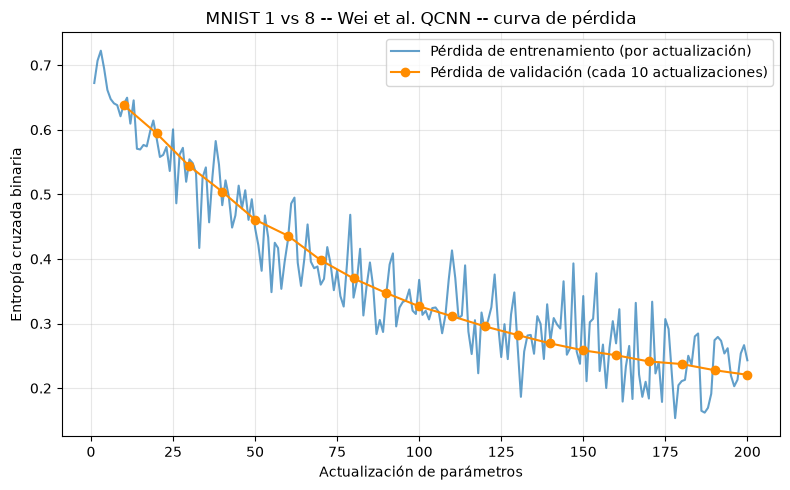

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, result_1v8["n_updates_run"] + 1), result_1v8["train_loss_history"],
        label="Pérdida de entrenamiento (por actualización)", alpha=0.7)
val_updates, val_losses = zip(*result_1v8["val_loss_history"])
ax.plot(val_updates, val_losses, "o-", label="Pérdida de validación (cada 10 actualizaciones)", color="darkorange")
if result_1v8["stopped_early_at"]:
    ax.axvline(result_1v8["stopped_early_at"], color="red", linestyle="--", alpha=0.6, label="Early stopping")
ax.set_xlabel("Actualización de parámetros")
ax.set_ylabel("Entropía cruzada binaria")
ax.set_title("MNIST 1 vs 8 -- Wei et al. QCNN -- curva de pérdida")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
params_1v8 = result_1v8["params"]

train_acc_1v8 = batch_accuracy(params_1v8, rep_1v8["X_train"], rep_1v8["y_train"])
test_acc_1v8 = batch_accuracy(params_1v8, rep_1v8["X_test"], rep_1v8["y_test"])

TARGET_ACC = 96.3
gap_pp = test_acc_1v8 * 100 - TARGET_ACC

print("=" * 70)
print("MNIST 1 vs 8 -- Wei et al. QCNN, 1 semilla de ejecución")
print("=" * 70)
print(f"Exactitud de entrenamiento: {train_acc_1v8 * 100:.2f}%")
print(f"Exactitud de prueba:        {test_acc_1v8 * 100:.2f}%")
print(f"Objetivo publicado (Tabla I, sin ruido): {TARGET_ACC}%")
print(f"Diferencia (prueba - objetivo): {gap_pp:+.2f} puntos porcentuales")
if abs(gap_pp) <= 1.0:
    print("-> Dentro de ~1pp del objetivo publicado: fidelidad razonable para 1 semilla.")
elif abs(gap_pp) <= 3.0:
    print("-> Brecha moderada (1-3pp). Aceptable para 1 semilla, pero conviene revisar antes de 10 semillas.")
else:
    print("-> Brecha grande (>3pp). PARAR: reportar al usuario en detalle antes de seguir "
          "ajustando hiperparámetros por cuenta propia -- puede ser una diferencia real de implementación.")

MNIST 1 vs 8 -- Wei et al. QCNN, 1 semilla de ejecución
Exactitud de entrenamiento: 93.80%
Exactitud de prueba:        94.80%
Objetivo publicado (Tabla I, sin ruido): 96.3%
Diferencia (prueba - objetivo): -1.50 puntos porcentuales
-> Brecha moderada (1-3pp). Aceptable para 1 semilla, pero conviene revisar antes de 10 semillas.


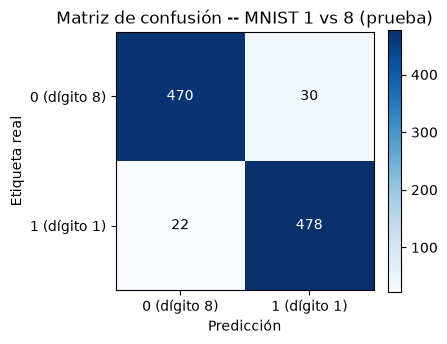

[[470  30]
 [ 22 478]]


In [8]:
y_pred_test_1v8 = np.array([
    1 if predict_proba(params_1v8, x) >= 0.5 else 0
    for x in rep_1v8["X_test"]
])
cm_1v8 = confusion_matrix(rep_1v8["y_test"], y_pred_test_1v8, labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_1v8, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["0 (dígito 8)", "1 (dígito 1)"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["0 (dígito 8)", "1 (dígito 1)"])
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión -- MNIST 1 vs 8 (prueba)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_1v8[i, j]), ha="center", va="center",
                color="white" if cm_1v8[i, j] > cm_1v8.max() / 2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
print(cm_1v8)

## 5.1 Diagnóstico — ¿la brecha de -1.5pp es por falta de convergencia?

La corrida de 200 actualizaciones de arriba dio 94.80% de exactitud de prueba
(objetivo: 96.3%), pero **ninguno de los 20 chequeos de validación dejó de
mejorar** (`no_improve=0` en los 20, ninguna activó early stopping) — la
pérdida de validación seguía bajando de forma casi monótona al llegar a la
actualización 200. Eso sugiere que 200 actualizaciones pueden no alcanzar
para que este circuito converja del todo (es más grande que el de Hur: 46
parámetros, un filtro LCU de 9 términos + hamiltoniano de 37).

Diagnóstico acordado con el usuario: repetir **solo esta corrida** (misma
semilla, mismos datos, mismos hiperparámetros) con más actualizaciones (500 en
vez de 200) para ver si la brecha se cierra por convergencia. No se toca
ningún otro hiperparámetro. Esto es un diagnóstico adicional, no reemplaza la
corrida oficial de 200 actualizaciones de la sección 5 (que es la que sigue el
protocolo exacto del benchmark).

[1v8-extended-500] update  10/500  train_loss=0.6397  val_loss=0.6378  best_val=0.6378  no_improve=0  t=8s


[1v8-extended-500] update  20/500  train_loss=0.5869  val_loss=0.5943  best_val=0.5943  no_improve=0  t=16s


[1v8-extended-500] update  30/500  train_loss=0.5542  val_loss=0.5436  best_val=0.5436  no_improve=0  t=25s


[1v8-extended-500] update  40/500  train_loss=0.4832  val_loss=0.5041  best_val=0.5041  no_improve=0  t=34s


[1v8-extended-500] update  50/500  train_loss=0.4478  val_loss=0.4608  best_val=0.4608  no_improve=0  t=43s


...

[1v8-extended-500] update 470/500  train_loss=0.2143  val_loss=0.1447  best_val=0.1447  no_improve=0  t=387s


[1v8-extended-500] update 480/500  train_loss=0.2464  val_loss=0.1506  best_val=0.1447  no_improve=1  t=395s


[1v8-extended-500] update 490/500  train_loss=0.1797  val_loss=0.1426  best_val=0.1426  no_improve=0  t=403s


[1v8-extended-500] update 500/500  train_loss=0.1650  val_loss=0.1409  best_val=0.1409  no_improve=0  t=412s


DIAGNOSTICO: MNIST 1 vs 8, misma semilla, 500 actualizaciones en vez de 200
Exactitud de entrenamiento: 94.30%  (200 updates: 93.80%)
Exactitud de prueba:        95.80%  (200 updates: 94.80%)
Objetivo publicado: 96.3%
Diferencia (prueba - objetivo): -0.50 puntos porcentuales  (200 updates: -1.50pp)
-> La brecha se REDUJO con mas actualizaciones: consistente con falta de convergencia a 200 updates, no con un bug de implementacion.


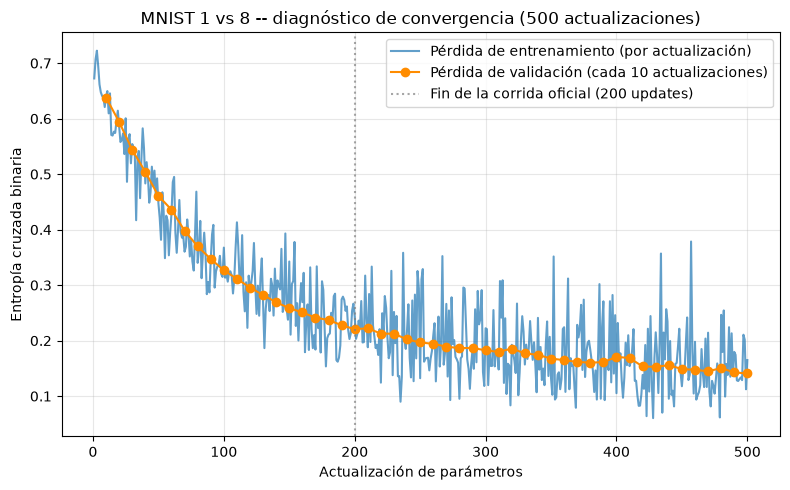

In [9]:
result_1v8_extended = train_wei(rep_1v8, tag="1v8-extended-500", n_updates=500)

params_1v8_ext = result_1v8_extended["params"]
train_acc_1v8_ext = batch_accuracy(params_1v8_ext, rep_1v8["X_train"], rep_1v8["y_train"])
test_acc_1v8_ext = batch_accuracy(params_1v8_ext, rep_1v8["X_test"], rep_1v8["y_test"])
gap_pp_ext = test_acc_1v8_ext * 100 - TARGET_ACC

print("=" * 70)
print("DIAGNOSTICO: MNIST 1 vs 8, misma semilla, 500 actualizaciones en vez de 200")
print("=" * 70)
print(f"Exactitud de entrenamiento: {train_acc_1v8_ext * 100:.2f}%  (200 updates: {train_acc_1v8 * 100:.2f}%)")
print(f"Exactitud de prueba:        {test_acc_1v8_ext * 100:.2f}%  (200 updates: {test_acc_1v8 * 100:.2f}%)")
print(f"Objetivo publicado: {TARGET_ACC}%")
print(f"Diferencia (prueba - objetivo): {gap_pp_ext:+.2f} puntos porcentuales  (200 updates: {gap_pp:+.2f}pp)")
if abs(gap_pp_ext) < abs(gap_pp):
    print("-> La brecha se REDUJO con mas actualizaciones: consistente con falta de convergencia a 200 updates, no con un bug de implementacion.")
else:
    print("-> La brecha NO se redujo (o empeoro) con mas actualizaciones: no parece ser un problema de convergencia -- revisar la implementacion del circuito antes de escalar a 10 semillas.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, result_1v8_extended["n_updates_run"] + 1), result_1v8_extended["train_loss_history"],
        label="Pérdida de entrenamiento (por actualización)", alpha=0.7)
val_updates_ext, val_losses_ext = zip(*result_1v8_extended["val_loss_history"])
ax.plot(val_updates_ext, val_losses_ext, "o-", label="Pérdida de validación (cada 10 actualizaciones)", color="darkorange")
if result_1v8_extended["stopped_early_at"]:
    ax.axvline(result_1v8_extended["stopped_early_at"], color="red", linestyle="--", alpha=0.6, label="Early stopping")
ax.axvline(200, color="gray", linestyle=":", alpha=0.7, label="Fin de la corrida oficial (200 updates)")
ax.set_xlabel("Actualización de parámetros")
ax.set_ylabel("Entropía cruzada binaria")
ax.set_title("MNIST 1 vs 8 -- diagnóstico de convergencia (500 actualizaciones)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Corrida B — Fashion-MNIST camiseta vs. pantalón (referencia, sin objetivo publicado)

Wei et al. no evalúan Fashion-MNIST en absoluto (solo MNIST 2-clases y
10-clases) — **no hay número publicado con el que comparar**. Se reporta como
referencia para el benchmark, con la misma codificación de amplitud (imagen
28×28 con padding a 32×32, norma L2, 1024 amplitudes). Convención de etiqueta:
$y=1$ para "T-shirt/top" (camiseta, clase 0 de Fashion-MNIST), $y=0$ para
"Trouser" (pantalón, clase 1 de Fashion-MNIST).

In [10]:
fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_FASHION_ALL = fashion.data.astype(np.float64)
Y_FASHION_ALL = fashion.target.astype(int)
print("Pool Fashion-MNIST:", X_FASHION_ALL.shape, Y_FASHION_ALL.shape)
print("0 = T-shirt/top (camiseta), 1 = Trouser (pantalón)")

rep_shirt_trouser = build_dataset(class_pos=0, class_neg=1, x_all=X_FASHION_ALL, y_all=Y_FASHION_ALL)

result_shirt_trouser = train_wei(rep_shirt_trouser, tag="shirt-trouser")

Pool Fashion-MNIST: (70000, 784) (70000,)
0 = T-shirt/top (camiseta), 1 = Trouser (pantalón)
  train: (1000, 1024), norma L2 promedio = 1.000000
  val: (500, 1024), norma L2 promedio = 1.000000
  test: (1000, 1024), norma L2 promedio = 1.000000


[shirt-trouser] update  10/200  train_loss=0.6693  val_loss=0.6687  best_val=0.6687  no_improve=0  t=8s


[shirt-trouser] update  20/200  train_loss=0.6150  val_loss=0.6217  best_val=0.6217  no_improve=0  t=16s


[shirt-trouser] update  30/200  train_loss=0.5958  val_loss=0.5734  best_val=0.5734  no_improve=0  t=25s


[shirt-trouser] update  40/200  train_loss=0.4920  val_loss=0.5277  best_val=0.5277  no_improve=0  t=33s


...

[shirt-trouser] update 160/200  train_loss=0.2643  val_loss=0.2703  best_val=0.2703  no_improve=0  t=129s


[shirt-trouser] update 170/200  train_loss=0.2899  val_loss=0.2549  best_val=0.2549  no_improve=0  t=137s


[shirt-trouser] update 180/200  train_loss=0.2847  val_loss=0.2474  best_val=0.2474  no_improve=0  t=145s


[shirt-trouser] update 190/200  train_loss=0.2130  val_loss=0.2413  best_val=0.2413  no_improve=0  t=153s


[shirt-trouser] update 200/200  train_loss=0.2296  val_loss=0.2294  best_val=0.2294  no_improve=0  t=161s


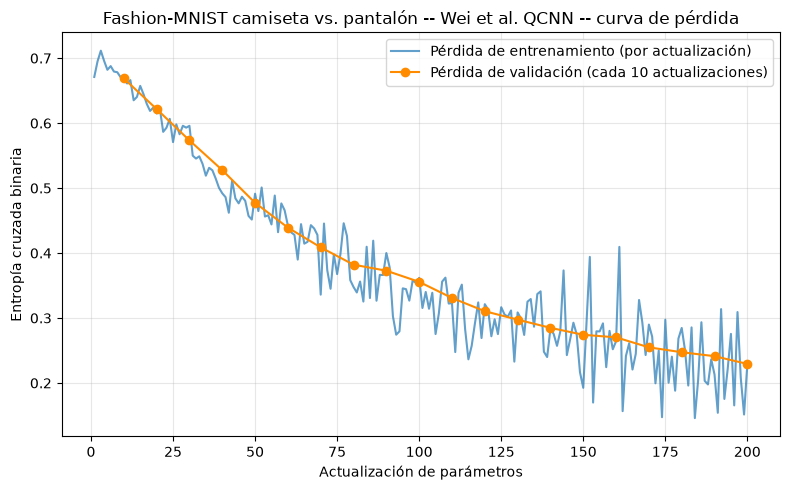

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, result_shirt_trouser["n_updates_run"] + 1), result_shirt_trouser["train_loss_history"],
        label="Pérdida de entrenamiento (por actualización)", alpha=0.7)
val_updates, val_losses = zip(*result_shirt_trouser["val_loss_history"])
ax.plot(val_updates, val_losses, "o-", label="Pérdida de validación (cada 10 actualizaciones)", color="darkorange")
if result_shirt_trouser["stopped_early_at"]:
    ax.axvline(result_shirt_trouser["stopped_early_at"], color="red", linestyle="--", alpha=0.6, label="Early stopping")
ax.set_xlabel("Actualización de parámetros")
ax.set_ylabel("Entropía cruzada binaria")
ax.set_title("Fashion-MNIST camiseta vs. pantalón -- Wei et al. QCNN -- curva de pérdida")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
params_shirt_trouser = result_shirt_trouser["params"]

train_acc_st = batch_accuracy(params_shirt_trouser, rep_shirt_trouser["X_train"], rep_shirt_trouser["y_train"])
test_acc_st = batch_accuracy(params_shirt_trouser, rep_shirt_trouser["X_test"], rep_shirt_trouser["y_test"])

print("=" * 70)
print("Fashion-MNIST camiseta vs. pantalón -- Wei et al. QCNN, 1 semilla de ejecución")
print("=" * 70)
print(f"Exactitud de entrenamiento: {train_acc_st * 100:.2f}%")
print(f"Exactitud de prueba:        {test_acc_st * 100:.2f}%")
print("Sin objetivo publicado por Wei et al. para esta tarea (no evalúan Fashion-MNIST) "
      "-- no se compara contra el 96.3% de MNIST 1v8, son tareas distintas.")

Fashion-MNIST camiseta vs. pantalón -- Wei et al. QCNN, 1 semilla de ejecución
Exactitud de entrenamiento: 95.60%
Exactitud de prueba:        95.10%
Sin objetivo publicado por Wei et al. para esta tarea (no evalúan Fashion-MNIST) -- no se compara contra el 96.3% de MNIST 1v8, son tareas distintas.


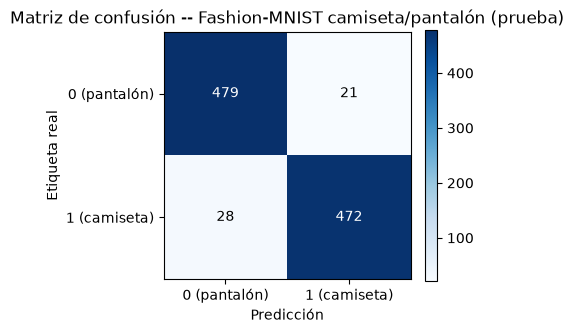

[[479  21]
 [ 28 472]]


In [13]:
y_pred_test_st = np.array([
    1 if predict_proba(params_shirt_trouser, x) >= 0.5 else 0
    for x in rep_shirt_trouser["X_test"]
])
cm_st = confusion_matrix(rep_shirt_trouser["y_test"], y_pred_test_st, labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_st, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["0 (pantalón)", "1 (camiseta)"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["0 (pantalón)", "1 (camiseta)"])
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión -- Fashion-MNIST camiseta/pantalón (prueba)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_st[i, j]), ha="center", va="center",
                color="white" if cm_st[i, j] > cm_st.max() / 2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
print(cm_st)

## 7. Resumen

| Tarea | Exactitud entrenamiento | Exactitud prueba | Objetivo Wei et al. | Comparable |
|---|---|---|---|---|
| MNIST 1 vs 8 | ver celda de resultados | ver celda de resultados | 96.3% (Tabla I, sin ruido) | Sí |
| Fashion-MNIST camiseta vs. pantalón | ver celda de resultados | ver celda de resultados | No publicado | No |

**Notas para la siguiente decisión:**

- MNIST 1v8 (200 updates, protocolo oficial) quedó -1.5pp por debajo del
  objetivo (94.80% vs 96.3%), sin señal de convergencia (ver sección 5.1 para
  el diagnóstico con 500 updates y si la brecha se explica por presupuesto de
  entrenamiento insuficiente en vez de un error de implementación).
- El circuito se construyó directamente del paper, no de `external/wei_qcnn`
  (esa base de código no es fiel a esta arquitectura — ver sección 0).
- La post-selección de las 4 ancillas se implementó como combinación lineal
  directa (exacta para el caso sin ruido). Si más adelante se necesita
  ejecución con ruido/shots, esa parte del circuito sí tendría que simular las
  ancillas explícitamente con puertas controladas y post-selección real —
  pendiente, no implementado hoy.
- No se creó ningún adaptador todavía; esto sigue siendo solo un notebook
  exploratorio de validación.